## Implementation Roadmap
- Variables
    - embeddings_dimension = 10
    - context_length = 3
    - m: number of examples (unique contexts)
    - unique_chars_len = 27 (26 chars + '.')
    - nn_h_l = 200, number of nruson in hidden layer
- Build Background
    - itoc
        - len = unique_chars_len
    - ctoi
- Build Context and Data Splitting
    - Context 
        - Construct new X and Y which has context and lable respectively
        - X: (m, context_length)
            - $v \in \text{unique char len}$  
        - Y: (m,)
    - Data Splitting
        - Train: 80%
        - Dev: 10%
        - Te: 10% 
- Theoretical layers
    1. Input
         - Pass Raw context thorugh embedding as input
         - lookup table
             - (unique_chars_len, embeddings_dimension) 
         - embeddings
             - shape: (m, context_length, embeddings_dimension)
         - output
             - squeeze embeddings to 2D 
                 - shape: (m, context_length * embeddings_dimension) 
    2. Hidden layer (nonlinearity)
         - tanh
         - shape: (context_length * embeddings_dimension, nn_h_l)
             - W1: (context_length * embeddings_dimension, nn_h_l)
             - b1: (nn_h_l,) 
    4. Ouput
         - softmax
         - (m, unique_chars_len)
             - w2: (nn_h_l, unique_chars_len)
             - b2: (unique_chars_len,)
- Construct MLP architecture key entities
    - lookup tables, W1, b1, W2, b2
- Training Steps
    - mini-batch
        - batch_size: 32
    - learning rate decay
    - forward
    - loss
    - backward
    - param updates
- Loss Showcase
- Read Papar and Fine Tune the hyper params
    - Hyper params
        - Embedding dimensions
        - number of neuron in hiddne layers (tanh)

In [254]:
"""
===========
All necessary background entities
===========
"""
import random

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

df = pd.read_csv('./assets/names.txt', sep = r'\s+', header = None)
words = df.squeeze().to_list()

"""
Layers
"""
# context length
ctx_len = 3
# embeddings dimension
emb_dim = 10
# number of unique chars from data
unq_chars_len = 27
# number of nruson in hidden layer
nn_h_l = 200


"""
Data Splitting
"""
# data splitting portion
train_por = 0.8
dev_por = 0.1
test_por = 0.1

"""
Generators
"""
# generator seed
np_seed = 42
g = torch.Generator().manual_seed(2147483647)
g_pred = torch.Generator().manual_seed(2147483647 + 10)

"""
Other hyperparams
"""
# learning rate
lr_d = 0.1
lr_threshold = 100000
lr_s = 0.01 
batch_size = 32


chars = ['.'] + sorted(list(set([char for word in words for char in word])))

itoc = {i:c for i, c in enumerate(chars)}
ctoi = {c:i for i,c in itoc.items()}
# Just assure that the unq_chars_len has correct length
unq_chars_len = len(ctoi)

In [255]:
"""
===========
Build Context & Data Splitting
# optional: from sklearn.model_selection import train_test_split
===========
"""
rng = np.random.default_rng(np_seed)
rng.shuffle(words)
# words = words[:100]

def build_data(words):
    X = []
    Y = []
    for w in words:
        w = w + '.'
        ctx = [0] * ctx_len
        for char in w:
            idx = ctoi[char]
            X.append(ctx)
            Y.append(idx)
            ctx = ctx[1:] + [idx]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

n1 = int(train_por * len(words))
n2 = int((train_por + dev_por) * len(words))

X_train, Y_train = build_data(words[:n1])
X_dev, Y_dev = build_data(words[n1:n2])
X_test, Y_test = build_data(words[n2:])

X_train.shape, Y_train.dtype, X_dev.shape, Y_dev.dtype, X_test.shape, X_test.dtype

(torch.Size([182531, 3]),
 torch.int64,
 torch.Size([22807, 3]),
 torch.int64,
 torch.Size([22808, 3]),
 torch.int64)

In [256]:
"""
===========
MLP Key Variables
===========
"""
# Lookup table
C = torch.randn((unq_chars_len, emb_dim), generator = g)
W1 = torch.randn((ctx_len * emb_dim, nn_h_l), generator = g)
b1 = torch.randn(nn_h_l, generator = g)
W2 = torch.randn((nn_h_l, unq_chars_len), generator = g)
b2 = torch.randn(unq_chars_len, generator = g)
params = [C, W1, b1, W2, b2]
for p in params:
    p.requires_grad = True

# Total number of params
sum([p.numel() for p in params])

11897

In [261]:
"""
===========
MLP Train Process
===========
"""
X = X_train
Y = Y_train
stepi = []
lossi = []



# _ is step/ith-iteration
for _ in range(200000):

    # forward propagation
    # batch_idxs
    bix = torch.randint(0, len(X), size = (batch_size, ))
    emb = C[X[bix]]
    z = emb.view(-1, ctx_len * emb_dim) @ W1 + b1
    h = torch.tanh(z)
    logits = h @ W2 + b2

    # loss
    loss = F.cross_entropy(logits, Y[bix])

    # backward propagation
    for p in params:
        p.grad = None
    loss.backward()

    lr = lr_d if _ < lr_threshold else lr_s
    
    # gradient descent
    for p in params:
        p.data += -lr * p.grad

    stepi.append(_)
    lossi.append(loss.log10().data)

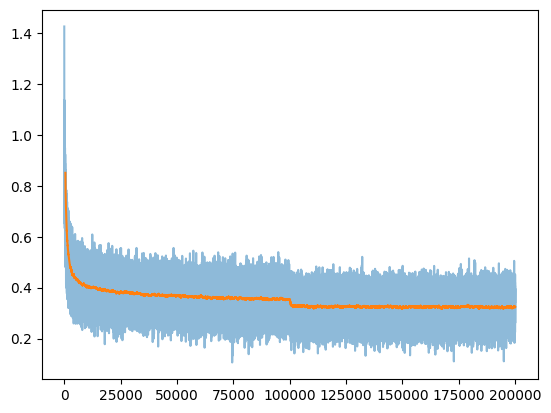

In [258]:
plt.plot(stepi, lossi, alpha = 0.5)

# plot moving average
# https://www.youtube.com/watch?v=Wo5YWXDRXv8
# https://numpy.org/devdocs/reference/generated/numpy.convolve.html
# mode="valid" -> overlap completely
window = 500  # try 100, 500, 2000
smooth_y = np.convolve(lossi, np.ones(window)/window, mode="valid")
smooth_x = stepi[window-1:]
plt.plot(smooth_x, smooth_y)

In [259]:
"""
===========
dev/validation test loss
===========
"""
def loss(X, Y):
    emb = C[X]
    z = emb.view(-1, ctx_len * emb_dim) @ W1 + b1
    h = torch.tanh(z)
    logits = h @ W2 + b2
    return F.cross_entropy(logits, Y).item()

dev_loss = loss(X_dev, Y_dev)
test_loss = loss(X_test, Y_test)
dev_loss, test_loss

(2.1500213146209717, 2.1710875034332275)

In [260]:
"""
===========
Prediction
===========
"""

for i in range(20):
    out = []
    ctx = [0] * ctx_len
    while True:
        emb = C[torch.tensor(ctx)]
        z = emb.view(-1, ctx_len * emb_dim) @ W1 + b1
        h = torch.tanh(z)
        logits = h @ W2 + b2
        # https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.softmax.html
        probs = F.softmax(logits, dim = 1)
        idx = torch.multinomial(probs, num_samples = 1, replacement = True, generator = g_pred).item()
        ctx = ctx[1:] + [idx]
        c = itoc[idx]
        out.append(c)
        if idx == 0:
            break
    print(''.join(out))

carmah.
ambrilli.
kimili.
taty.
skanden.
jazonelle.
jirra.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
joce.
quinthoror.
malianni.
wazell.
dearyni.
jaxeenivali.
edderi.
abette.
